# 05 Data Cleaning, Preprocessing and Transformation​

### Handling missing values


In [3]:
import pandas as pd
data = {
    'A': [1, 2, None, 4],
    'B': [5, None, 7, 8]
}
df = pd.DataFrame(data)

df

,A,B
0,1.0,5.0
1,2.0,NaN
2,NaN,7.0
3,4.0,8.0


In [5]:
# drop rows with missing values
dfDrop = df.dropna()
dfDrop

,A,B
0,1.0,5.0
3,4.0,8.0


In [6]:
# fill missing values with a specific value
dfFill = df.fillna(0)
dfFill

,A,B
0,1.0,5.0
1,2.0,0.0
2,0.0,7.0
3,4.0,8.0


### Scaling


In [7]:
import numpy as np
data = np.array(
    [
        [1, 2],
        [3, 4],
        [5, 6]
    ]
)
data

array([[1, 2],
       [3, 4],
       [5, 6]])

In [8]:
minVal = np.min(data, axis=0)
maxVal = np.max(data, axis=0)

scaledData = (data-minVal) / (maxVal-minVal)
print(scaledData)

[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


### Exploratory Data Analysis (EDA)

In [10]:
# define a sample dataframe for student data
data = {
    'studentID': np.arange(1, 6),
    'name': ['john', 'emily', 'michael', 'sophia', 'william'],
    'age': [20, 21, 19, 22, 20],
    'grade': [3.8, 3.9, 3.5, 4.0, 3.7],
    'major': ['computer science', 'biology', 'mathematics', 'engineering', 'psychology']
}
studentDF = pd.DataFrame(data)
studentDF

,studentID,name,age,grade,major
0,1,john,20,3.8,computer science
1,2,emily,21,3.9,biology
2,3,michael,19,3.5,mathematics
3,4,sophia,22,4.0,engineering
4,5,william,20,3.7,psychology


In [11]:
# descriptive statistics

# summary statistics with pandas
summaryStats = studentDF.describe()
summaryStats

,studentID,age,grade
count,5.000000,5.000000,5.000000
mean,3.000000,20.400000,3.780000
std,1.581139,1.140175,0.192354
min,1.000000,19.000000,3.500000
25%,2.000000,20.000000,3.700000
50%,3.000000,20.000000,3.800000
75%,4.000000,21.000000,3.900000
max,5.000000,22.000000,4.000000


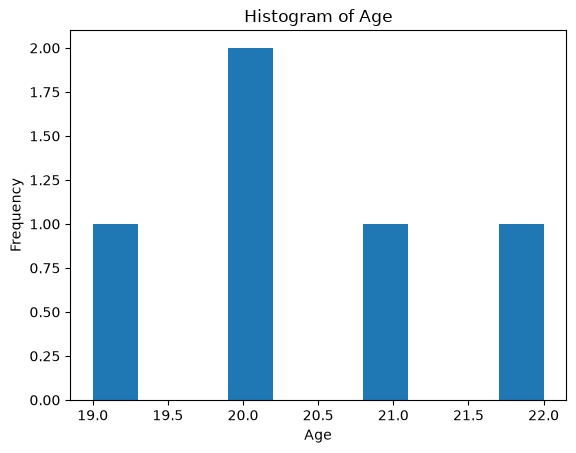

In [12]:
# data distribution
import matplotlib.pyplot as plt

# histogram
plt.hist(studentDF['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

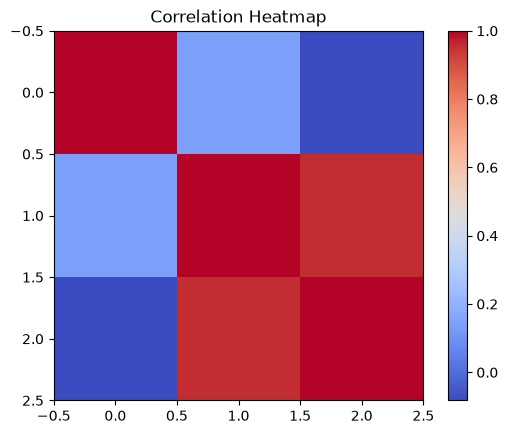

In [14]:
# Data Exploration

# correlation heatmap
correlationMatrix = studentDF.corr(numeric_only=True)
plt.imshow(correlationMatrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()

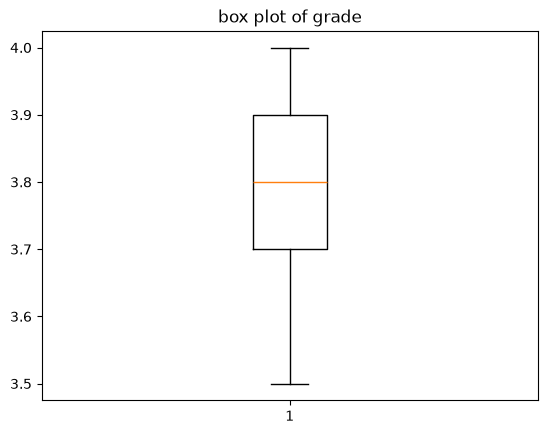

In [15]:
# box plot
plt.boxplot(studentDF['grade'])
plt.title('box plot of grade')
plt.show()

In [16]:
# detect outliners using z-score
zScore = (studentDF['grade'] - np.mean(studentDF['grade'])) / np.std(studentDF['grade'])

outliners = studentDF[(zScore > 3) | (zScore < -3)]
outliners

,studentID,name,age,grade,major
